# Challenge : Reconnaissance d'actions à partir de données plantaires
- **But** : classifier l'action en cours (action recognition) à partir des données d'empreintes plantaires.
- **Données** : 32 sujets (S01 - S32). Split proposé : 24 sujets pour l'entrainement/validation, 8 sujets pour le test.
- **Livrables** : <span style="color:red"> A FIXER</span>

## Organisation du dataset
- `Events/` : annotations d'évènements par sujet/séquence (fichiers `classif.csv`).
- `Plantar_activity/` : signaux plantaires par sujet/séquence (fichiers `insoles.csv`).

### Format `classif.csv` (annotations)
- Séparateur `;`. Colonnes :
  - `Name` : nom de l'action (ex. `Standing in T-pose`).
  - `Class` : identifiant numérique de la classe (float dans le fichier, ex. `1.0`).
  - `Frame Start`, `Frame End` : indices de frame
  - `Timestamp Start`, `Timestamp End` : temps en secondes (alignables avec les capteurs).
- Les actions se succèdent et couvrent toute la séquence.

### Format `insoles.csv` (capteurs)
- Séparateur `;`. Première colonne `Time` (s).
- Pour chaque pied :
  - 16 pressions (N/cm?) : `left pressure 1..16`, `right pressure 1..16`.
  - 3 accélérations (g) : `acceleration X/Y/Z`.
  - 3 vitesses angulaires (dps) : `angular X/Y/Z`.
  - 1 force totale (N) : `total force`.
  - 2 coordonnées de centre de pression : `center of pressure X[-0.5...+0.5]`, `center of pressure Y[-0.5...+0.5]`.
- Total : 1 (Time) + 25 features gauche + 25 features droite = 51 colonnes.


### Alignement annotations / capteurs
- Les timestamps start/end des actions (en s) permettent d'extraire la fenètre correspondante dans `insoles.csv`.
- Fréquence d’échantillonnage : 100 fps (≈100 valeurs par seconde, donc ~100 lignes pour couvrir 1 seconde de données).

## Split sujets
- **Train/val** : sujets S01 - S24 (24 sujets).
- **Test** : sujets S25 - S32 (8 sujets).

## Chargement & DataLoader (PyTorch)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm # Import tqdm

ROOT = Path(__file__).resolve().parent / "DataChallenge_donnees" if "__file__" in dir() else Path(".").resolve() / "DataChallenge_donnees"
events_root = ROOT / "Events"
plantar_root = ROOT / "Plantar_activity"
print("ok")

from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from tqdm import tqdm

class WindowedPlantarDataset(Dataset):
    def __init__(self, subjects, duration_s=3.0, fps=100, transform=None, threshold=0.70, label_encoder=None):
        self.samples = []  # tuples: (plantar_file_path, start_idx, window_len, label_str)
        self.transform = transform
        self.window_len = int(round(duration_s * fps))
        self.loaded_data = {}
        self.n_features = 0
        self.threshold = threshold

        def overlap_len(a0, a1, b0, b1):

            return max(0.0, min(a1, b1) - max(a0, b0))

        print("Loading dataset...")
        for sid in tqdm(subjects, desc="Processing subjects"):
            s_name = f"S{sid:02d}"
            ev_dir = events_root / s_name
            pl_dir = plantar_root / s_name
            if not ev_dir.exists() or not pl_dir.exists():
                continue

            for ev_file in ev_dir.rglob("classif.csv"):
                seq_name = ev_file.parent.name
                plantar_file_path = pl_dir / seq_name / "insoles.csv"
                if not plantar_file_path.exists():
                    continue

                # Load plantar data
                if plantar_file_path not in self.loaded_data:
                    df_insoles = pd.read_csv(plantar_file_path, sep=';')
                    self.loaded_data[plantar_file_path] = df_insoles

                df_insoles = self.loaded_data[plantar_file_path]
                times = df_insoles["Time"].values

                ann = pd.read_csv(ev_file, sep=';').copy()

                ann["Timestamp Start"] = ann["Timestamp Start"].astype(float)
                ann["Timestamp End"] = ann["Timestamp End"].astype(float)
                if len(ann) <= 2:
                  continue

                ann = ann.iloc[1:-1].reset_index(drop=True)

                for idx, row in ann.iterrows():
                    start_t = float(row["Timestamp Start"])
                    end_t   = float(row["Timestamp End"])
                    cls_cur = row["Class"]

                    win_start = start_t
                    win_end   = start_t + duration_s


                    cur_overlap = overlap_len(win_start, win_end, start_t, end_t)
                    ratio = cur_overlap / duration_s

                    if ratio >= self.threshold:
                        label = cls_cur
                    else:

                        if idx + 1 < len(ann):
                            label = ann.loc[idx + 1, "Class"]

                        else:
                            continue


                    start_idx = int(np.searchsorted(times, win_start))
                    end_idx   = start_idx + self.window_len

                    if end_idx > len(times):
                        continue

                    self.samples.append((plantar_file_path, start_idx, self.window_len, label))

        raw_labels = [lbl for _, _, _, lbl in self.samples]
        if label_encoder is None:
            self.le = LabelEncoder()
            self.labels = self.le.fit_transform(raw_labels)
        else:
            self.le = label_encoder
            self.labels = self.le.transform(raw_labels)

        print(f"Dataset loaded with {len(self.samples)} samples across {len(self.le.classes_)} classes.")

        if self.loaded_data:
            first_df = next(iter(self.loaded_data.values()))
            self.n_features = first_df.drop(columns=["Time"]).shape[1]
        print(f"Number of features (n_features) for this dataset: {self.n_features}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        plantar_file_path, start_idx, window_len, label_str = self.samples[idx]
        df = self.loaded_data[plantar_file_path]

        x = df.drop(columns=["Time"]).iloc[start_idx:start_idx + window_len].values.astype(np.float32)
        y = self.le.transform([label_str])[0]

        x = torch.from_numpy(x)
        y = torch.tensor(y, dtype=torch.long)

        if self.transform:
            x = self.transform(x)

        return x, y

train_subjects = list(range(1, 21))   # 1–20
val_subjects   = list(range(21, 28))  # 21–24
test_subjects  = list(range(28, 33))  # 25–32

train_ds = WindowedPlantarDataset(train_subjects, duration_s=3.0, fps=100)
val_ds  = WindowedPlantarDataset(val_subjects,  duration_s=3.0, fps=100 , label_encoder=train_ds.le)
test_ds  = WindowedPlantarDataset(test_subjects,  duration_s=3.0, fps=100 , label_encoder=train_ds.le)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False)

ok
Loading dataset...


Processing subjects: 100%|██████████| 20/20 [03:41<00:00, 11.09s/it]


Dataset loaded with 5973 samples across 30 classes.
Number of features (n_features) for this dataset: 50
Loading dataset...


Processing subjects: 100%|██████████| 7/7 [01:17<00:00, 11.05s/it]


Dataset loaded with 2097 samples across 30 classes.
Number of features (n_features) for this dataset: 50
Loading dataset...


Processing subjects: 100%|██████████| 5/5 [00:51<00:00, 10.35s/it]

Dataset loaded with 1491 samples across 30 classes.
Number of features (n_features) for this dataset: 50


In [4]:
import numpy as np

def class_distribution(ds):
    y = np.array(ds.labels)
    counts = np.bincount(y)
    class_names = ds.le.inverse_transform(np.arange(len(counts)))

    print("Distribution des classes :")
    for name, c in zip(class_names, counts):
        print(f"{str(name):>15} : {c:6d}  ({c / len(y) * 100:6.2f}%)")

    print("  total:", len(y))
    print("  nb classes:", len(counts))
    print("  min:", counts.min(), " | max:", counts.max())

print("TRAIN")
class_distribution(train_ds)

print("\nTEST")
class_distribution(test_ds)

TRAIN
Distribution des classes :
            2.0 :    200  (  3.35%)
            3.0 :    196  (  3.28%)
            4.0 :    193  (  3.23%)
            5.0 :    201  (  3.37%)
            6.0 :    204  (  3.42%)
            7.0 :    194  (  3.25%)
            8.0 :    202  (  3.38%)
            9.0 :    201  (  3.37%)
           10.0 :    202  (  3.38%)
           11.0 :    202  (  3.38%)
           12.0 :    204  (  3.42%)
           13.0 :    200  (  3.35%)
           14.0 :    189  (  3.16%)
           15.0 :    188  (  3.15%)
           16.0 :    199  (  3.33%)
           17.0 :    194  (  3.25%)
           18.0 :    195  (  3.26%)
           19.0 :    192  (  3.21%)
           20.0 :    199  (  3.33%)
           21.0 :    199  (  3.33%)
           22.0 :    198  (  3.31%)
           23.0 :    201  (  3.37%)
           24.0 :    204  (  3.42%)
           25.0 :    193  (  3.23%)
           26.0 :    204  (  3.42%)
           27.0 :    208  (  3.48%)
           28.0 :    202  (  3.

**Note** : Cet exemple est volontairement élémentaire pour illustrer un chargement de dataset. D’autres réflexions et choix (fenêtre temporelle, normalisation, encodage) sont attendus  et doivent être justifiés.

## Modèle, Entrainement, Evaluation

In [5]:
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from tqdm.auto import trange

class SimpleNet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(128, n_classes)

    def forward(self, x):  # x: [B, T, F]
        x = x.transpose(1, 2)       # -> [B, F, T]
        x = self.backbone(x).squeeze(-1)
        return self.head(x)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return loss_sum / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            loss_sum += loss.item() * y.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item(); total += y.size(0)
            all_pred.append(pred.cpu().numpy()); all_true.append(y.cpu().numpy())
    all_pred = np.concatenate(all_pred); all_true = np.concatenate(all_true)
    cm = confusion_matrix(all_true, all_pred)
    acc = correct / total
    return loss_sum / total, acc, cm, all_true, all_pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
n_classes = len(train_ds.le.classes_)
n_features = train_ds.n_features


model = SimpleNet(n_features, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_curve, val_curve = [], []
best_val_acc = 0.0
save_path = "/content/drive/MyDrive/best_model.pth"
for epoch in trange(1, 20, desc="Training Epochs"):
    tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, device)
    va_loss, va_acc, cm, y_true, y_pred = evaluate(model, val_dl, criterion, device)
    train_curve.append((tr_loss, tr_acc)); val_curve.append((va_loss, va_acc))
    print(f"Epoch {epoch:02d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), save_path)
        print(" Nouveau modèle sauvegardé ")

Using device: cuda


Training Epochs:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | train acc 0.311 | val acc 0.466
 Nouveau modèle sauvegardé 
Epoch 02 | train acc 0.496 | val acc 0.529
 Nouveau modèle sauvegardé 
Epoch 03 | train acc 0.555 | val acc 0.540
 Nouveau modèle sauvegardé 
Epoch 04 | train acc 0.591 | val acc 0.577
 Nouveau modèle sauvegardé 
Epoch 05 | train acc 0.613 | val acc 0.581
 Nouveau modèle sauvegardé 
Epoch 06 | train acc 0.627 | val acc 0.604
 Nouveau modèle sauvegardé 
Epoch 07 | train acc 0.643 | val acc 0.584
Epoch 08 | train acc 0.657 | val acc 0.596
Epoch 09 | train acc 0.665 | val acc 0.605
 Nouveau modèle sauvegardé 
Epoch 10 | train acc 0.670 | val acc 0.617
 Nouveau modèle sauvegardé 
Epoch 11 | train acc 0.685 | val acc 0.609
Epoch 12 | train acc 0.686 | val acc 0.618
 Nouveau modèle sauvegardé 
Epoch 13 | train acc 0.697 | val acc 0.621
 Nouveau modèle sauvegardé 
Epoch 14 | train acc 0.701 | val acc 0.609
Epoch 15 | train acc 0.710 | val acc 0.627
 Nouveau modèle sauvegardé 
Epoch 16 | train acc 0.709 | val acc 0.628
 Nou

**Note** : Le choix du modèle, des hyperparamètres, des métriques, du scheduler et du protocole de validation n’est ici qu’un exemple minimal. Vous devez proposer, tester et justifier vos propres choix (architecture, early stopping, équilibrage des classes) en fonction du problème et des résultats observés.

## Reporting : courbes, matrice de confusion, accuracy par classe

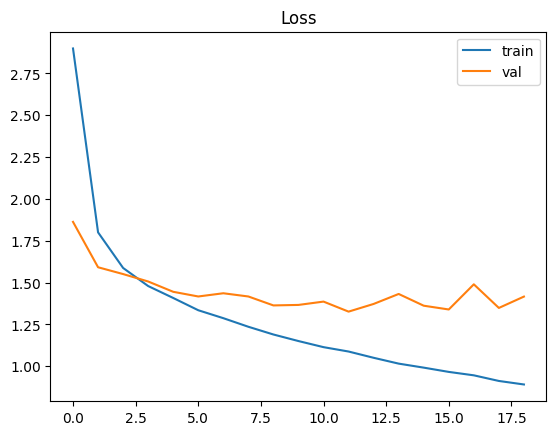

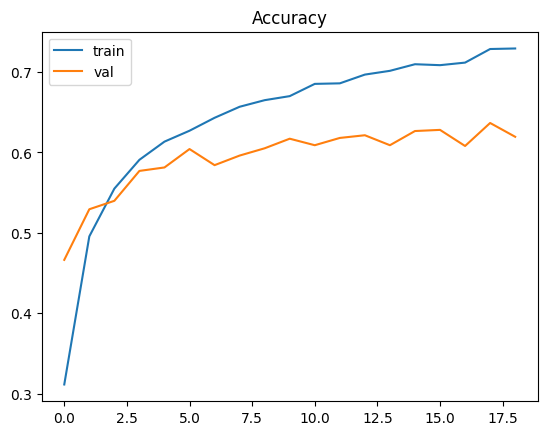

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

tr_loss = [x[0] for x in train_curve]; tr_acc = [x[1] for x in train_curve]
va_loss = [x[0] for x in val_curve];   va_acc = [x[1] for x in val_curve]

plt.figure(); plt.plot(tr_loss, label="train"); plt.plot(va_loss, label="val"); plt.title("Loss"); plt.legend();
plt.figure(); plt.plot(tr_acc, label="train"); plt.plot(va_acc, label="val"); plt.title("Accuracy"); plt.legend();


TEST | loss 1.2969 | acc 0.6680


Text(0.5, 1.0, 'Matrice de Confusion - Test set')

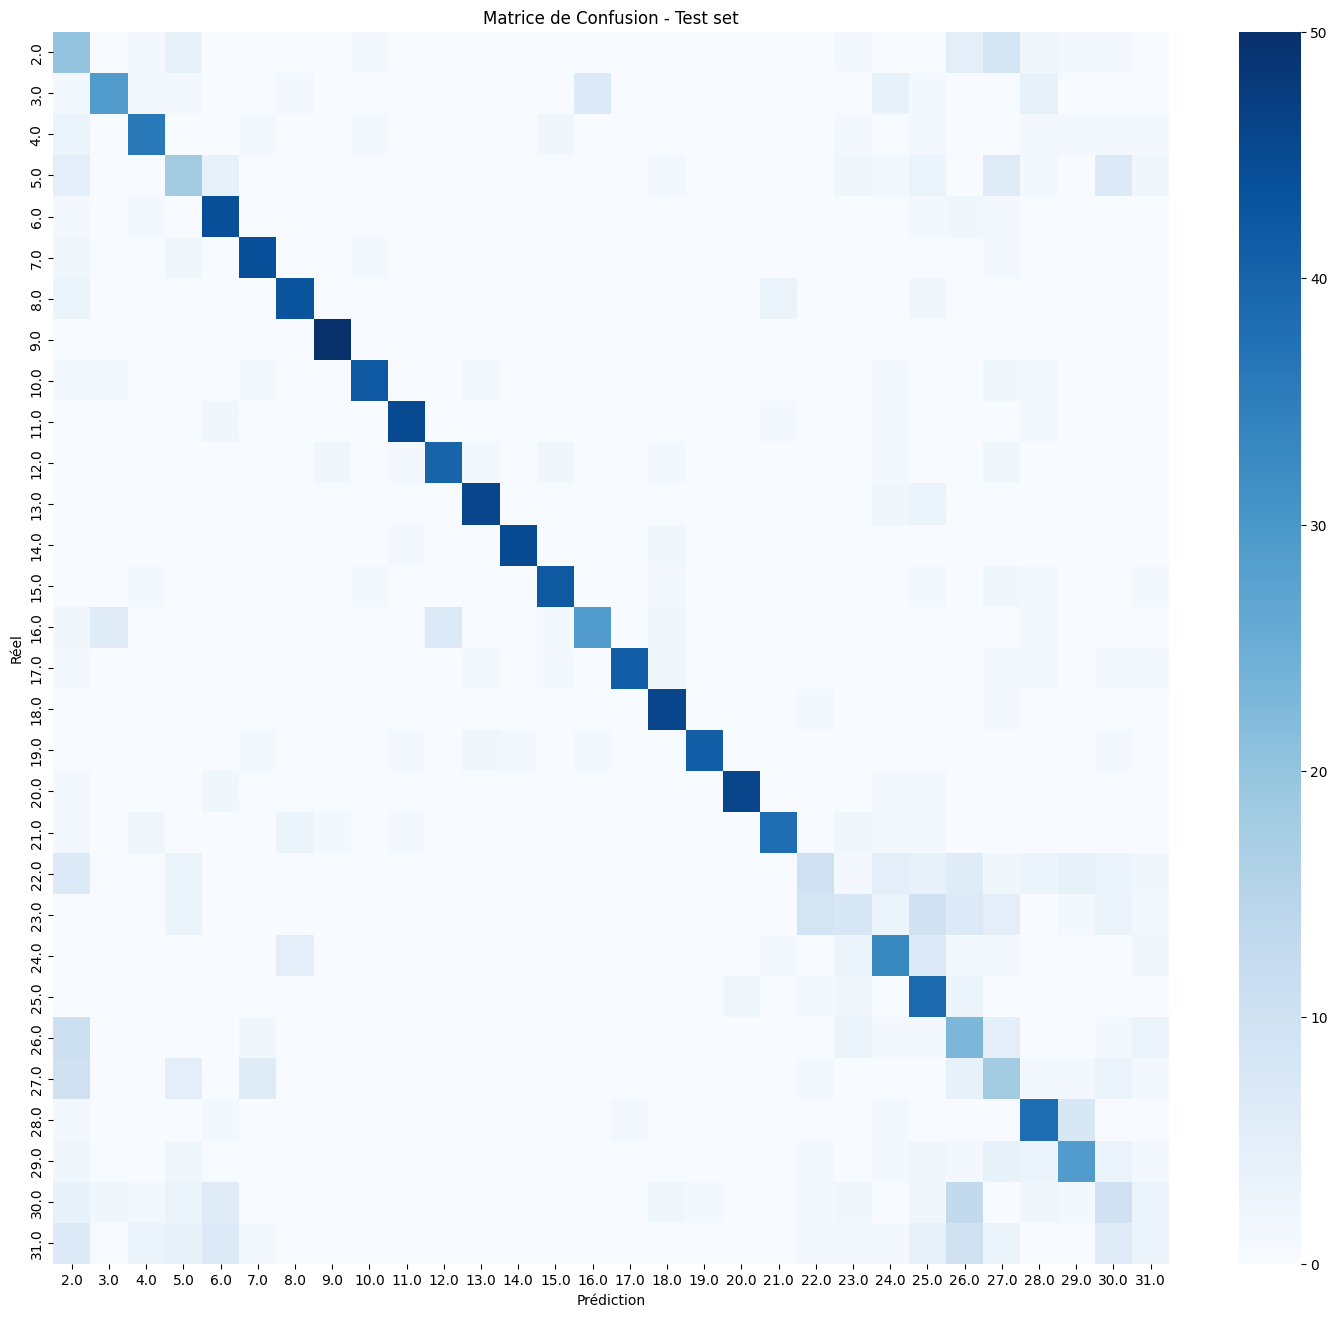

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_model = SimpleNet(n_features, n_classes).to(device)
best_model.load_state_dict(torch.load(save_path, map_location=device))
best_model.eval()
test_loss, test_acc, cm, y_true, y_pred = evaluate(best_model, test_dl, criterion, device)
print(f"TEST | loss {test_loss:.4f} | acc {test_acc:.4f}")


class_names = [str(c) for c in train_ds.le.classes_]


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18,16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de Confusion - Test set")

## Consignes pour le projet

- **Analyse exploratoire** : stats descriptives par feature (min, max, moyenne, écart-type), distribution des classes, détection d’outliers/valeurs manquantes, analyse du déséquilibre.
- **Prétraitement / chargement** : adapter le parsing de `classif.csv` et `insoles.csv` (fenêtrage, stride, gestion des longueurs variables), choisir la normalisation/standardisation et justifier chaque choix.
- **Modélisation** : proposer une architecture adaptée aux signaux temporels/spatiaux, paramétrage argumenté (fenêtre, profondeur, régularisation).
- **Évaluation** : utiliser des métriques pertinentes (accuracy, F1 macro/weighted, matrice de confusion, accuracy par classe), analyser les classes confondues.
- **Rapport et présentation** : un rapport synthétique + une courte présentation sont demandés pour l’évaluation. Inclure des courbes,graphes statistiques, des tableaux comparatifs de modèles/essais, et une analyse critique pour valoriser vos travaux. Chaque décision doit être motivée par vos observations et résultats.
